In [18]:
# initialisation
Ra = 1200
Rb = 1300
K  = 20 # plus le K est élevé plus l'Elo varie fortement
        # dans le classement fide, il est de 20 généralement
print("Classement elo du joueur A : ",Ra)
print("Classement elo du joueur B : ",Rb)
# calcul de la probabilité de victoire
Ea = 1 / (1 + 10 ** ((Rb - Ra) / 400))
Eb = 1 - Ea  

print(f"Probabilité : A a {Ea*100:.1f}% de chance de gagner.")


# calcul des 3 scénarios possibles

# cas 1 : A gagne (score réel de A = 1)
Ra_gagne = Ra + K * (1 - Ea)
Rb_perd  = Rb + K * (0 - Eb)
print(f"Si A gagne : A devient {Ra_gagne:.0f} | B devient {Rb_perd:.0f}")

# cas 2 : Match Nul (score réel de A = 0.5)
Ra_nul = Ra + K * (0.5 - Ea)
Rb_nul = Rb + K * (0.5 - Eb)
print(f"Si Nul     : A devient {Ra_nul:.0f} | B devient {Rb_nul:.0f}")

# cas 3 : B gagne (score réel de A = 0)
Ra_perd = Ra + K * (0 - Ea)
Rb_gagne = Rb + K * (1 - Eb)
print(f"Si B gagne : A devient {Ra_perd:.0f} | B devient {Rb_gagne:.0f}")

Classement elo du joueur A :  1200
Classement elo du joueur B :  1300
Probabilité : A a 36.0% de chance de gagner.
Si A gagne : A devient 1213 | B devient 1287
Si Nul     : A devient 1203 | B devient 1297
Si B gagne : A devient 1193 | B devient 1307


Classements finaux :
Magnus : 2038.86 (niveau réel : 2000)
Pierre : 1710.41 (niveau réel : 1750)
Colin : 1430.44 (niveau réel : 1500)
Aure : 1283.62 (niveau réel : 1250)
Paul : 1036.67 (niveau réel : 1000)


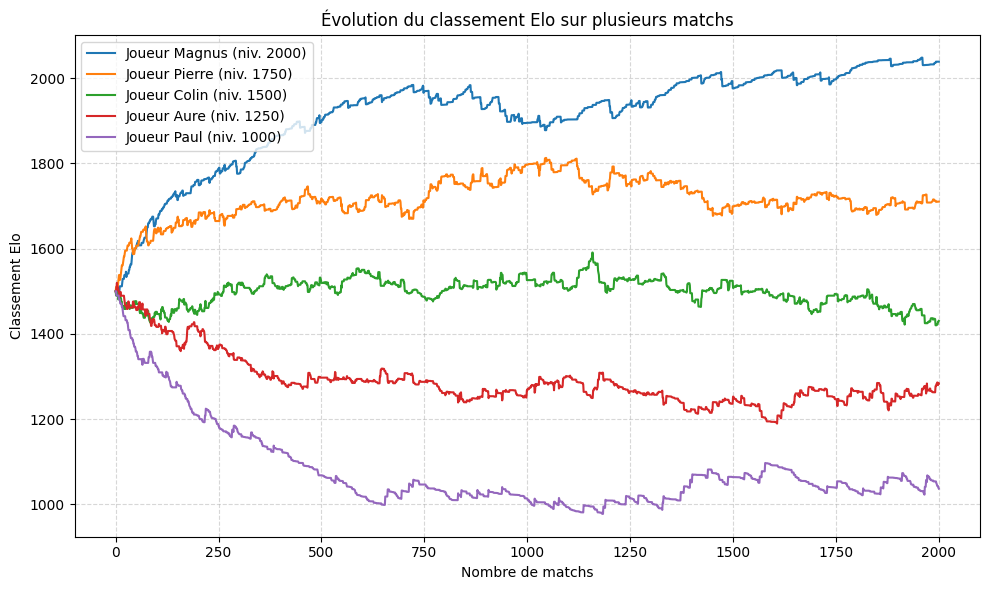

In [ ]:
import random
import matplotlib.pyplot as plt

# initialisation des joueurs
# chaque joueur a :
# - un classement Elo initial
# - un niveau intrinsèque (niveau_reel) servant à déterminer ses performances
joueurs = {
    "Magnus": {"elo": 1500, "niveau_reel": 2000},
    "Pierre": {"elo": 1500, "niveau_reel": 1750},
    "Colin": {"elo": 1500, "niveau_reel": 1500},
    "Aure": {"elo": 1500, "niveau_reel": 1250},
    "Paul": {"elo": 1500, "niveau_reel": 1000},
}

K = 20           # Facteur d’ajustement
n_matchs = 2000  

# historique des Elo (pour le graphique)
historique = {j: [info["elo"]] for j, info in joueurs.items()}


# fonction de probabilité que le joueur A batte le joueur B
def proba_victoire(Ra, Rb):
    return 1 / (1 + 10 ** ((Rb - Ra) / 400))


# simulation des matchs
for i in range(n_matchs):
    # choix de deux joueurs différents au hasard
    A, B = random.sample(list(joueurs.keys()), 2)
    Ra, Rb = joueurs[A]["elo"], joueurs[B]["elo"]
    Na, Nb = joueurs[A]["niveau_reel"], joueurs[B]["niveau_reel"]

    # probabilités de victoire selon les niveaux intrinsèques (et non les Elo)
    Ea_reel = proba_victoire(Na, Nb)

    # Simulation du résultat basé sur le niveau réel
    Sa = 1 if random.random() < Ea_reel else 0
    Sb = 1 - Sa

    # probabilités attendues selon Elo (pour mise à jour)
    Ea_elo = proba_victoire(Ra, Rb)
    Eb_elo = 1 - Ea_elo

    # mise à jour des classements Elo
    joueurs[A]["elo"] = Ra + K * (Sa - Ea_elo)
    joueurs[B]["elo"] = Rb + K * (Sb - Eb_elo)

    # mise à jour de l'historique
    for j in joueurs:
        historique[j].append(joueurs[j]["elo"])


# classements finaux
print("Classements finaux :")
for j, info in sorted(joueurs.items(), key=lambda x: x[1]["elo"], reverse=True):
    print(f"{j} : {info['elo']:.2f} (niveau réel : {info['niveau_reel']})")


# graphique
plt.figure(figsize=(10, 6))
for j, valeurs in historique.items():
    plt.plot(valeurs, label=f"Joueur {j} (niv. {joueurs[j]['niveau_reel']})")

plt.title("Évolution du classement Elo sur plusieurs matchs")
plt.xlabel("Nombre de matchs")
plt.ylabel("Classement Elo")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Application du système ELO à la Premier League

Traitement de la saison 2023/2024...
Calibration terminée. Les équipes attaquent 2024/2025 avec leur vrai niveau.
Traitement de la saison 2024/2025...

--- COMPARAISON CLASSEMENT ELO vs RÉEL (2024/2025) ---
        Équipe  Elo Final  Rang Elo  Rang Réel  Écart
     Liverpool     1668.3         1          1      0
       Arsenal     1660.8         2          2      0
      Man City     1653.0         3          3      0
       Chelsea     1601.4         4          4      0
   Aston Villa     1590.2         5          6      1
     Newcastle     1571.2         6          5      1
      Brighton     1550.9         7          8      1
Crystal Palace     1545.9         8         12      4
 Nott'm Forest     1528.9         9          7      2
       Everton     1521.8        10         13      3
   Bournemouth     1520.0        11          9      2
     Brentford     1515.4        12         10      2
        Fulham     1507.6        13         11      2
    Man United     1471.9        14  

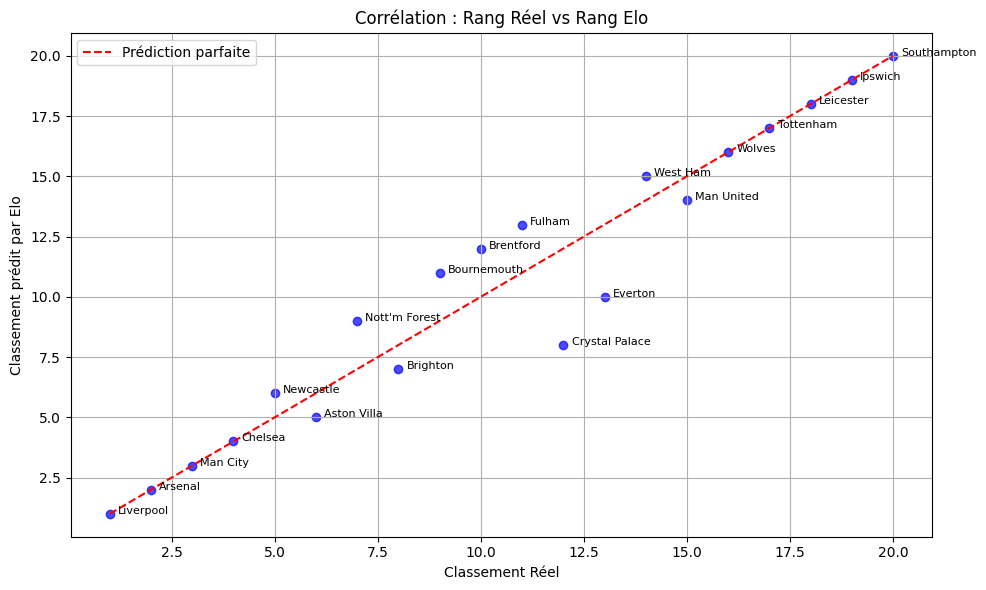

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# config
K = 20  # coefficient d'ajustement 
ELO_DEPART = 1500  # point de départ pour calibrer et pour les équipes n'ayant pas d'historique (promus)


try:
    df_saison_precedente = pd.read_csv("E1.csv")[["HomeTeam", "AwayTeam", "FTR"]].dropna()
    df_saison_actuelle = pd.read_csv("E0.csv")[["HomeTeam", "AwayTeam", "FTR"]].dropna()
except FileNotFoundError:
    print("Erreur : Assurez-vous que E0.csv et E1.csv sont bien présents.")
    exit()

# dictionnaire pour stocker les Elos actuels : { "Liverpool": 1600, etc ... }
elos = {}

# fonction du système elo

#calcul de la probabilité de victoire de A face à B
def get_proba(elo_a, elo_b):
    return 1 / (1 + 10 ** ((elo_b - elo_a) / 400))

#mise à jour les Elos après un match
def update_elo(elo_home, elo_away, resultat, k_factor):
    resultat_home = {"H": 1, "D": 0.5, "A": 0}[resultat]
    proba_home = get_proba(elo_home, elo_away)

    delta = k_factor * (resultat_home - proba_home)

    return elo_home + delta, elo_away - delta

def traiter_matchs(df, elos_dict, save_history=False):
   
    history = {} # Pour stocker l'évolution 

    # initialisation de l'historique pour les équipes existantes
    if save_history:
        for team, rating in elos_dict.items():
            history[team] = [rating]

    for _, row in df.iterrows():
        home, away, res = row["HomeTeam"], row["AwayTeam"], row["FTR"]

        # si une équipe est nouvelle (promue ou début de simu), on l'initialise
        if home not in elos_dict: elos_dict[home] = ELO_DEPART
        if away not in elos_dict: elos_dict[away] = ELO_DEPART

        # initialisation historique pour les nouveaux venus
        if save_history:
            if home not in history: history[home] = [elos_dict[home]]
            if away not in history: history[away] = [elos_dict[away]]

        # calcul et mise à jour
        new_home, new_away = update_elo(elos_dict[home], elos_dict[away], res, K)
        elos_dict[home] = new_home
        elos_dict[away] = new_away

        # historique pour le graphique
        if save_history:
            history[home].append(new_home)
            history[away].append(new_away)

    return history

# étape 1 : calibrage (saison 23/24) 
print("Traitement de la saison 2023/2024...")
traiter_matchs(df_saison_precedente, elos, save_history=False)
print("Calibration terminée. Les équipes attaquent 2024/2025 avec leur vrai niveau.")

# étape 2 : test sur la saison actuelle (saison 24/25) 
print("Traitement de la saison 2024/2025...")
historique_elo = traiter_matchs(df_saison_actuelle, elos, save_history=True)

# comparatif final

# le classement réel (saison 24/25)
classement_reel_dict = {
    "Liverpool": 1, "Arsenal": 2, "Man City": 3, "Chelsea": 4, "Newcastle": 5,
    "Aston Villa": 6, "Nott'm Forest": 7, "Brighton": 8, "Bournemouth": 9,
    "Brentford": 10, "Fulham": 11, "Crystal Palace": 12, "Everton": 13,
    "West Ham": 14, "Man United": 15, "Wolves": 16, "Tottenham": 17,
    "Leicester": 18, "Ipswich": 19, "Southampton": 20
}

# création du tableau comparatif
data_final = []
# On trie les équipes par leur Elo final (décroissant) pour avoir le classement Elo
equipes_triees = sorted(elos.items(), key=lambda x: x[1], reverse=True)

# on filtre pour ne garder que les équipes présentes dans la saison actuelle (E0)
equipes_actuelles = set(df_saison_actuelle["HomeTeam"]) | set(df_saison_actuelle["AwayTeam"])

rang_elo = 1
for equipe, score in equipes_triees:
    if equipe in equipes_actuelles:
        c_reel = classement_reel_dict.get(equipe, "N/A")
        ecart = abs(rang_elo - c_reel) if isinstance(c_reel, int) else 0

        data_final.append({
            "Équipe": equipe,
            "Elo Final": round(score, 1),
            "Rang Elo": rang_elo,
            "Rang Réel": c_reel,
            "Écart": ecart
        })
        rang_elo += 1

df_resultats = pd.DataFrame(data_final)
print("\n--- COMPARAISON CLASSEMENT ELO vs RÉEL (2024/2025) ---")
print(df_resultats.to_string(index=False))


# nuage de points pour comparer avec la prédiction parfaite
plt.figure(figsize=(10, 6))
plt.scatter(df_resultats["Rang Réel"], df_resultats["Rang Elo"], color='blue', alpha=0.7)

plt.plot([1, 20], [1, 20], color='red', linestyle='--', label="Prédiction parfaite")

# labels
for i, row in df_resultats.iterrows():
    if isinstance(row["Rang Réel"], int): # Sécurité
        plt.text(row["Rang Réel"] + 0.2, row["Rang Elo"], row["Équipe"], fontsize=8)

plt.title("Corrélation : Rang Réel vs Rang Elo")
plt.xlabel("Classement Réel")
plt.ylabel("Classement prédit par Elo")


plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


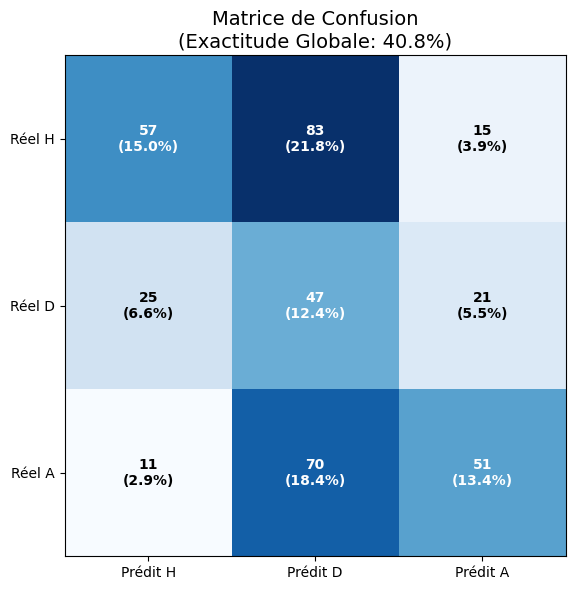

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#paramètres
K = 20
ELO_DEPART = 1200
#seuil pour prédire match nul
SEUIL_HAUT = 0.60
SEUIL_BAS = 0.40

# chargement
try:
    df_saison_precedente = pd.read_csv("E1.csv")[["HomeTeam", "AwayTeam", "FTR"]].dropna()
    df_saison_actuelle = pd.read_csv("E0.csv")[["HomeTeam", "AwayTeam", "FTR"]].dropna()
except FileNotFoundError:
    print("Erreur : Fichiers E0.csv ou E1.csv manquants.")
    exit()

elos = {}

# fonction elo
def get_proba(elo_a, elo_b):
    return 1 / (1 + 10 ** ((elo_b - elo_a) / 400))

def update_elo(elo_home, elo_away, resultat, k_factor):
    resultat_val = {"H": 1, "D": 0.5, "A": 0}[resultat]
    proba_home = get_proba(elo_home, elo_away)
    delta = k_factor * (resultat_val - proba_home)
    return elo_home + delta, elo_away - delta

def predire_match(proba):
    if proba > SEUIL_HAUT: return "H"
    elif proba < SEUIL_BAS: return "A"
    else: return "D"


# calibration en fonction de la saison précédente
for _, row in df_saison_precedente.iterrows():
    h, a, res = row["HomeTeam"], row["AwayTeam"], row["FTR"]
    if h not in elos: elos[h] = ELO_DEPART
    if a not in elos: elos[a] = ELO_DEPART
    elos[h], elos[a] = update_elo(elos[h], elos[a], res, K)

# prédiction (saison actuelle)
y_true = []
y_pred = []

for _, row in df_saison_actuelle.iterrows():
    h, a, res = row["HomeTeam"], row["AwayTeam"], row["FTR"]
    if h not in elos: elos[h] = ELO_DEPART
    if a not in elos: elos[a] = ELO_DEPART

    proba = get_proba(elos[h], elos[a])
    pred = predire_match(proba)

    y_true.append(res)
    y_pred.append(pred)

    elos[h], elos[a] = update_elo(elos[h], elos[a], res, K)

# --- CALCUL DES MÉTRIQUES ---
labels = ["H", "D", "A"] 
# h : home victory
# d : draw
# a : away victory
label_map = {l: i for i, l in enumerate(labels)}
cm = np.zeros((3, 3), dtype=int)

for v, p in zip(y_true, y_pred):
    cm[label_map[v], label_map[p]] += 1

#affichage de la matrice de confusion

fig, ax1 = plt.subplots(figsize=(8, 6))

im = ax1.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax1.set_title(f"Matrice de Confusion\n(Exactitude Globale: {acc:.1%})", fontsize=14)

tick_marks = np.arange(3)
ax1.set_xticks(tick_marks)
ax1.set_xticklabels(["Prédit H", "Prédit D", "Prédit A"])
ax1.set_yticks(tick_marks)
ax1.set_yticklabels(["Réel H", "Réel D", "Réel A"])

thresh = cm.max() / 2.
for i in range(3):
    for j in range(3):
        count = cm[i, j]
        pct = (count / cm.sum()) * 100 
        text_str = f"{count}\n({pct:.1f}%)"
        ax1.text(j, i, text_str, ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black",
                 fontweight='bold')

plt.tight_layout()
plt.show()